# 图表反演

In [6]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

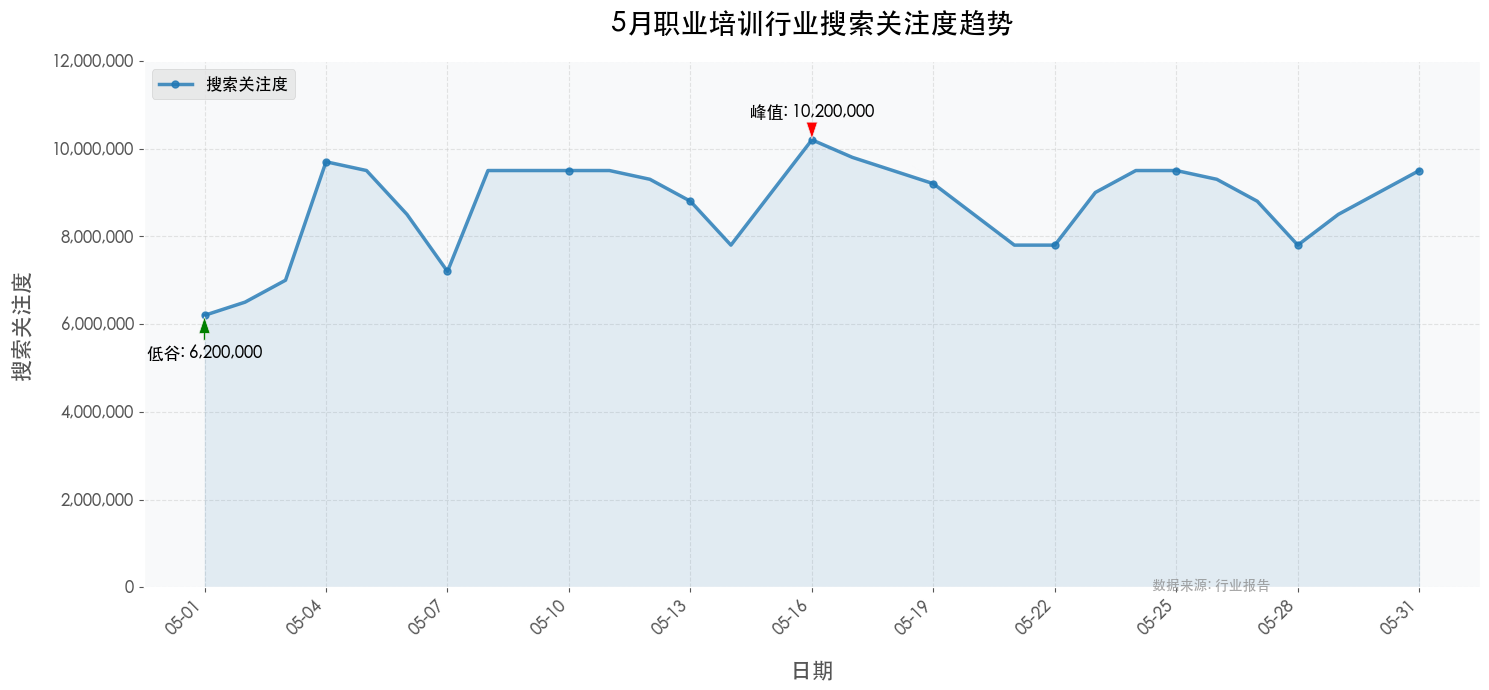

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# 数据直接放在列表中（日期格式：'YYYY-MM-DD'，数值为完整数值）
dates = ['2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04', '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08', '2025-05-09', '2025-05-10', '2025-05-11', '2025-05-12', '2025-05-13', '2025-05-14', '2025-05-15', '2025-05-16', '2025-05-17', '2025-05-18', '2025-05-19', '2025-05-20', '2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30', '2025-05-31']
search_attention = [6200000, 6500000, 7000000, 9700000, 9500000, 8500000, 7200000, 9500000, 9500000, 9500000, 9500000, 9300000, 8800000, 7800000, 9000000, 10200000, 9800000, 9500000, 9200000, 8500000, 7800000, 7800000, 9000000, 9500000, 9500000, 9300000, 8800000, 7800000, 8500000, 9000000, 9500000]

# 将日期字符串转换为datetime对象
dates = [datetime.strptime(date, '%Y-%m-%d') for date in dates]

# 创建画布和子图，增加图表大小
fig, ax = plt.subplots(figsize=(15, 7))

# 设置背景样式
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')

# 绘制折线图，添加透明度和标记点
line, = ax.plot(dates, search_attention, color='#1f77b4', linewidth=2.5, alpha=0.8, marker='o', markersize=5, markevery=3)

# 添加填充区域
ax.fill_between(dates, search_attention, 0, color='#1f77b4', alpha=0.1)

# 设置 x 轴为日期格式，每3天显示一个刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

# 设置图表标题和坐标轴标签，增加字体大小和样式
ax.set_title('5月职业培训行业搜索关注度趋势', fontsize=20, pad=20, fontweight='bold')
ax.set_ylabel('搜索关注度', fontsize=16, labelpad=15)
ax.set_xlabel('日期', fontsize=16, labelpad=15)

# 设置 y 轴刻度范围和格式，添加千位分隔符
ax.set_ylim(0, 12000000)
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

# 添加网格线，设置样式
ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc')

# 自定义刻度标签字体大小
ax.tick_params(axis='both', which='major', labelsize=12)

# 让 x 轴日期自动调整间距，避免重叠
fig.autofmt_xdate(rotation=45, ha='right')

# 添加最大值和最小值标注
max_val = max(search_attention)
min_val = min(search_attention)
max_idx = search_attention.index(max_val)
min_idx = search_attention.index(min_val)

ax.annotate(f'峰值: {max_val:,}',
            xy=(dates[max_idx], max_val),
            xytext=(dates[max_idx], max_val + 500000),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12,
            ha='center')

ax.annotate(f'低谷: {min_val:,}',
            xy=(dates[min_idx], min_val),
            xytext=(dates[min_idx], min_val - 1000000),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12,
            ha='center')

# 添加图例
ax.legend([line], ['搜索关注度'], loc='upper left', fontsize=12)

# 添加水印
fig.text(0.85, 0.15, '数据来源: 行业报告', fontsize=10, color='gray', alpha=0.7, ha='right')

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()    

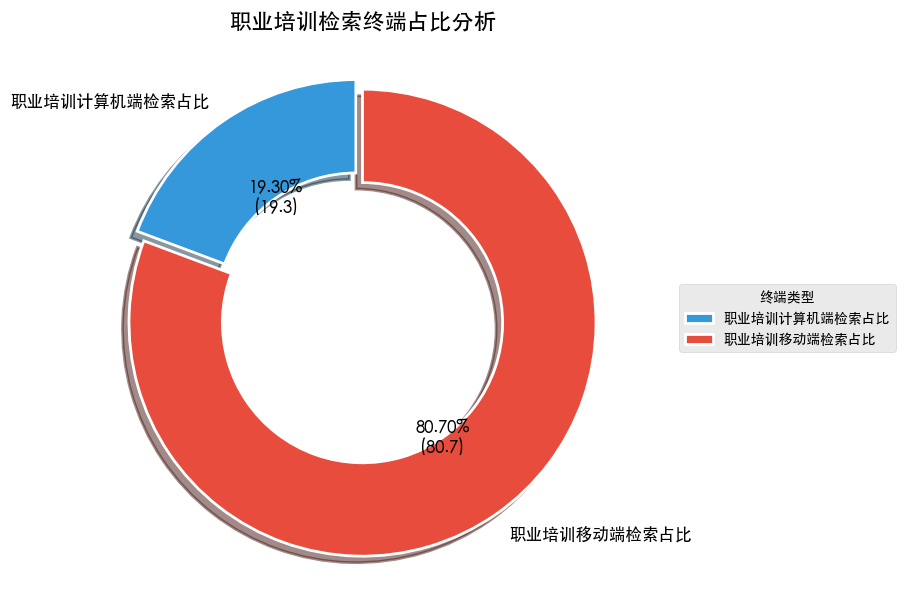

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['职业培训计算机端检索占比', '职业培训移动端检索占比']
sizes = [19.30, 80.70]
# 更现代的配色方案
colors = ['#3498db', '#e74c3c']  
# 突出显示移动端部分
explode = (0, 0.05)  

# 创建图形和轴，设置图形大小
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制环形图，添加阴影效果和百分比文本格式优化
wedges, texts, autotexts = ax.pie(sizes, 
                                explode=explode,
                                labels=labels,
                                autopct=lambda p: f'{p:.2f}%\n({p*sum(sizes)/100:.1f})',
                                startangle=90,
                                colors=colors,
                                wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2},
                                shadow=True,
                                textprops={'fontsize': 12})

# 设置标题和图例
ax.set_title('职业培训检索终端占比分析', fontsize=16, pad=20)
ax.legend(wedges, labels, title="终端类型", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 优化百分比文本样式 - 将颜色修改为深色
plt.setp(autotexts, size=12, weight="bold", color='black')  # 修改颜色为黑色
plt.setp(texts, size=12)

# 设置图形背景和布局
plt.tight_layout()
plt.axis('equal')  # 保证饼图是圆形
plt.subplots_adjust(right=0.8)  # 为图例留出空间

# 保存图形（可选）
# plt.savefig('职业培训检索终端占比.png', dpi=300, bbox_inches='tight')

# 显示图形
plt.show()

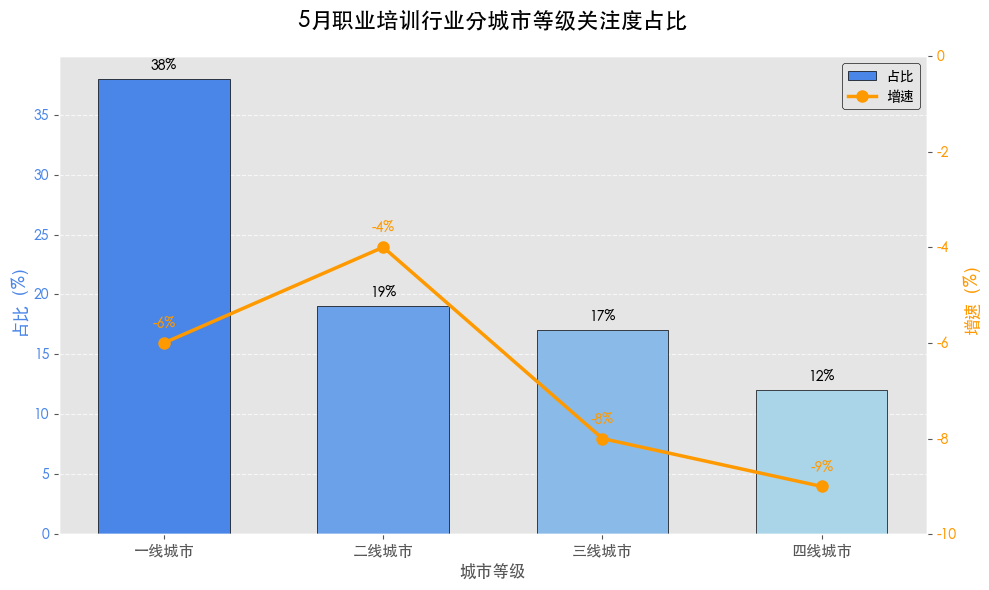

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
city_levels = ["一线城市", "二线城市", "三线城市", "四线城市"]
proportion = [38, 19, 17, 12]  # 占比数据
growth_rate = [-6, -4, -8, -9]  # 增速数据

x = np.arange(len(city_levels))  # x 轴刻度位置

# 创建图表
fig, ax1 = plt.subplots(figsize=(10, 6))  # 调整图表大小

# 设置背景样式 - 使用 Matplotlib 内置样式
plt.style.use('ggplot')  # 修改为 Matplotlib 内置样式

# 绘制柱状图（占比） - 使用渐变色
bar_colors = ['#4A86E8', '#6AA1E8', '#8ABBE8', '#AAD5E8']  # 蓝色渐变
bars = ax1.bar(x, proportion, color=bar_colors, label='占比', width=0.6, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('占比（%）', color='#4A86E8', fontsize=12)
ax1.set_xlabel('城市等级', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(city_levels, fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4A86E8')

# 在柱状图上方添加数据标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom', fontsize=10)

# 创建第二个 y 轴，绘制折线图（增速）
ax2 = ax1.twinx()
line_color = '#FF9900'  # 橙色
ax2.plot(x, growth_rate, color=line_color, label='增速', linewidth=2.5, marker='o', markersize=8)
ax2.set_ylabel('增速（%）', color=line_color, fontsize=12)
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.set_ylim([-10, 0])  # 设置增速轴的范围

# 在折线上添加数据标签
for i, txt in enumerate(growth_rate):
    ax2.annotate(f'{txt}%', (x[i], growth_rate[i]), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=10, color=line_color)

# 添加图例 - 使用更美观的样式
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', 
           frameon=True, framealpha=0.9, edgecolor='black', fancybox=True)

# 添加图表标题
plt.title('5月职业培训行业分城市等级关注度占比', fontsize=16, fontweight='bold', pad=20)

# 添加网格线增强可读性
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.grid(axis='x', visible=False)
ax2.grid(visible=False)

# 调整图表布局
plt.tight_layout()

# 显示图表
plt.show()

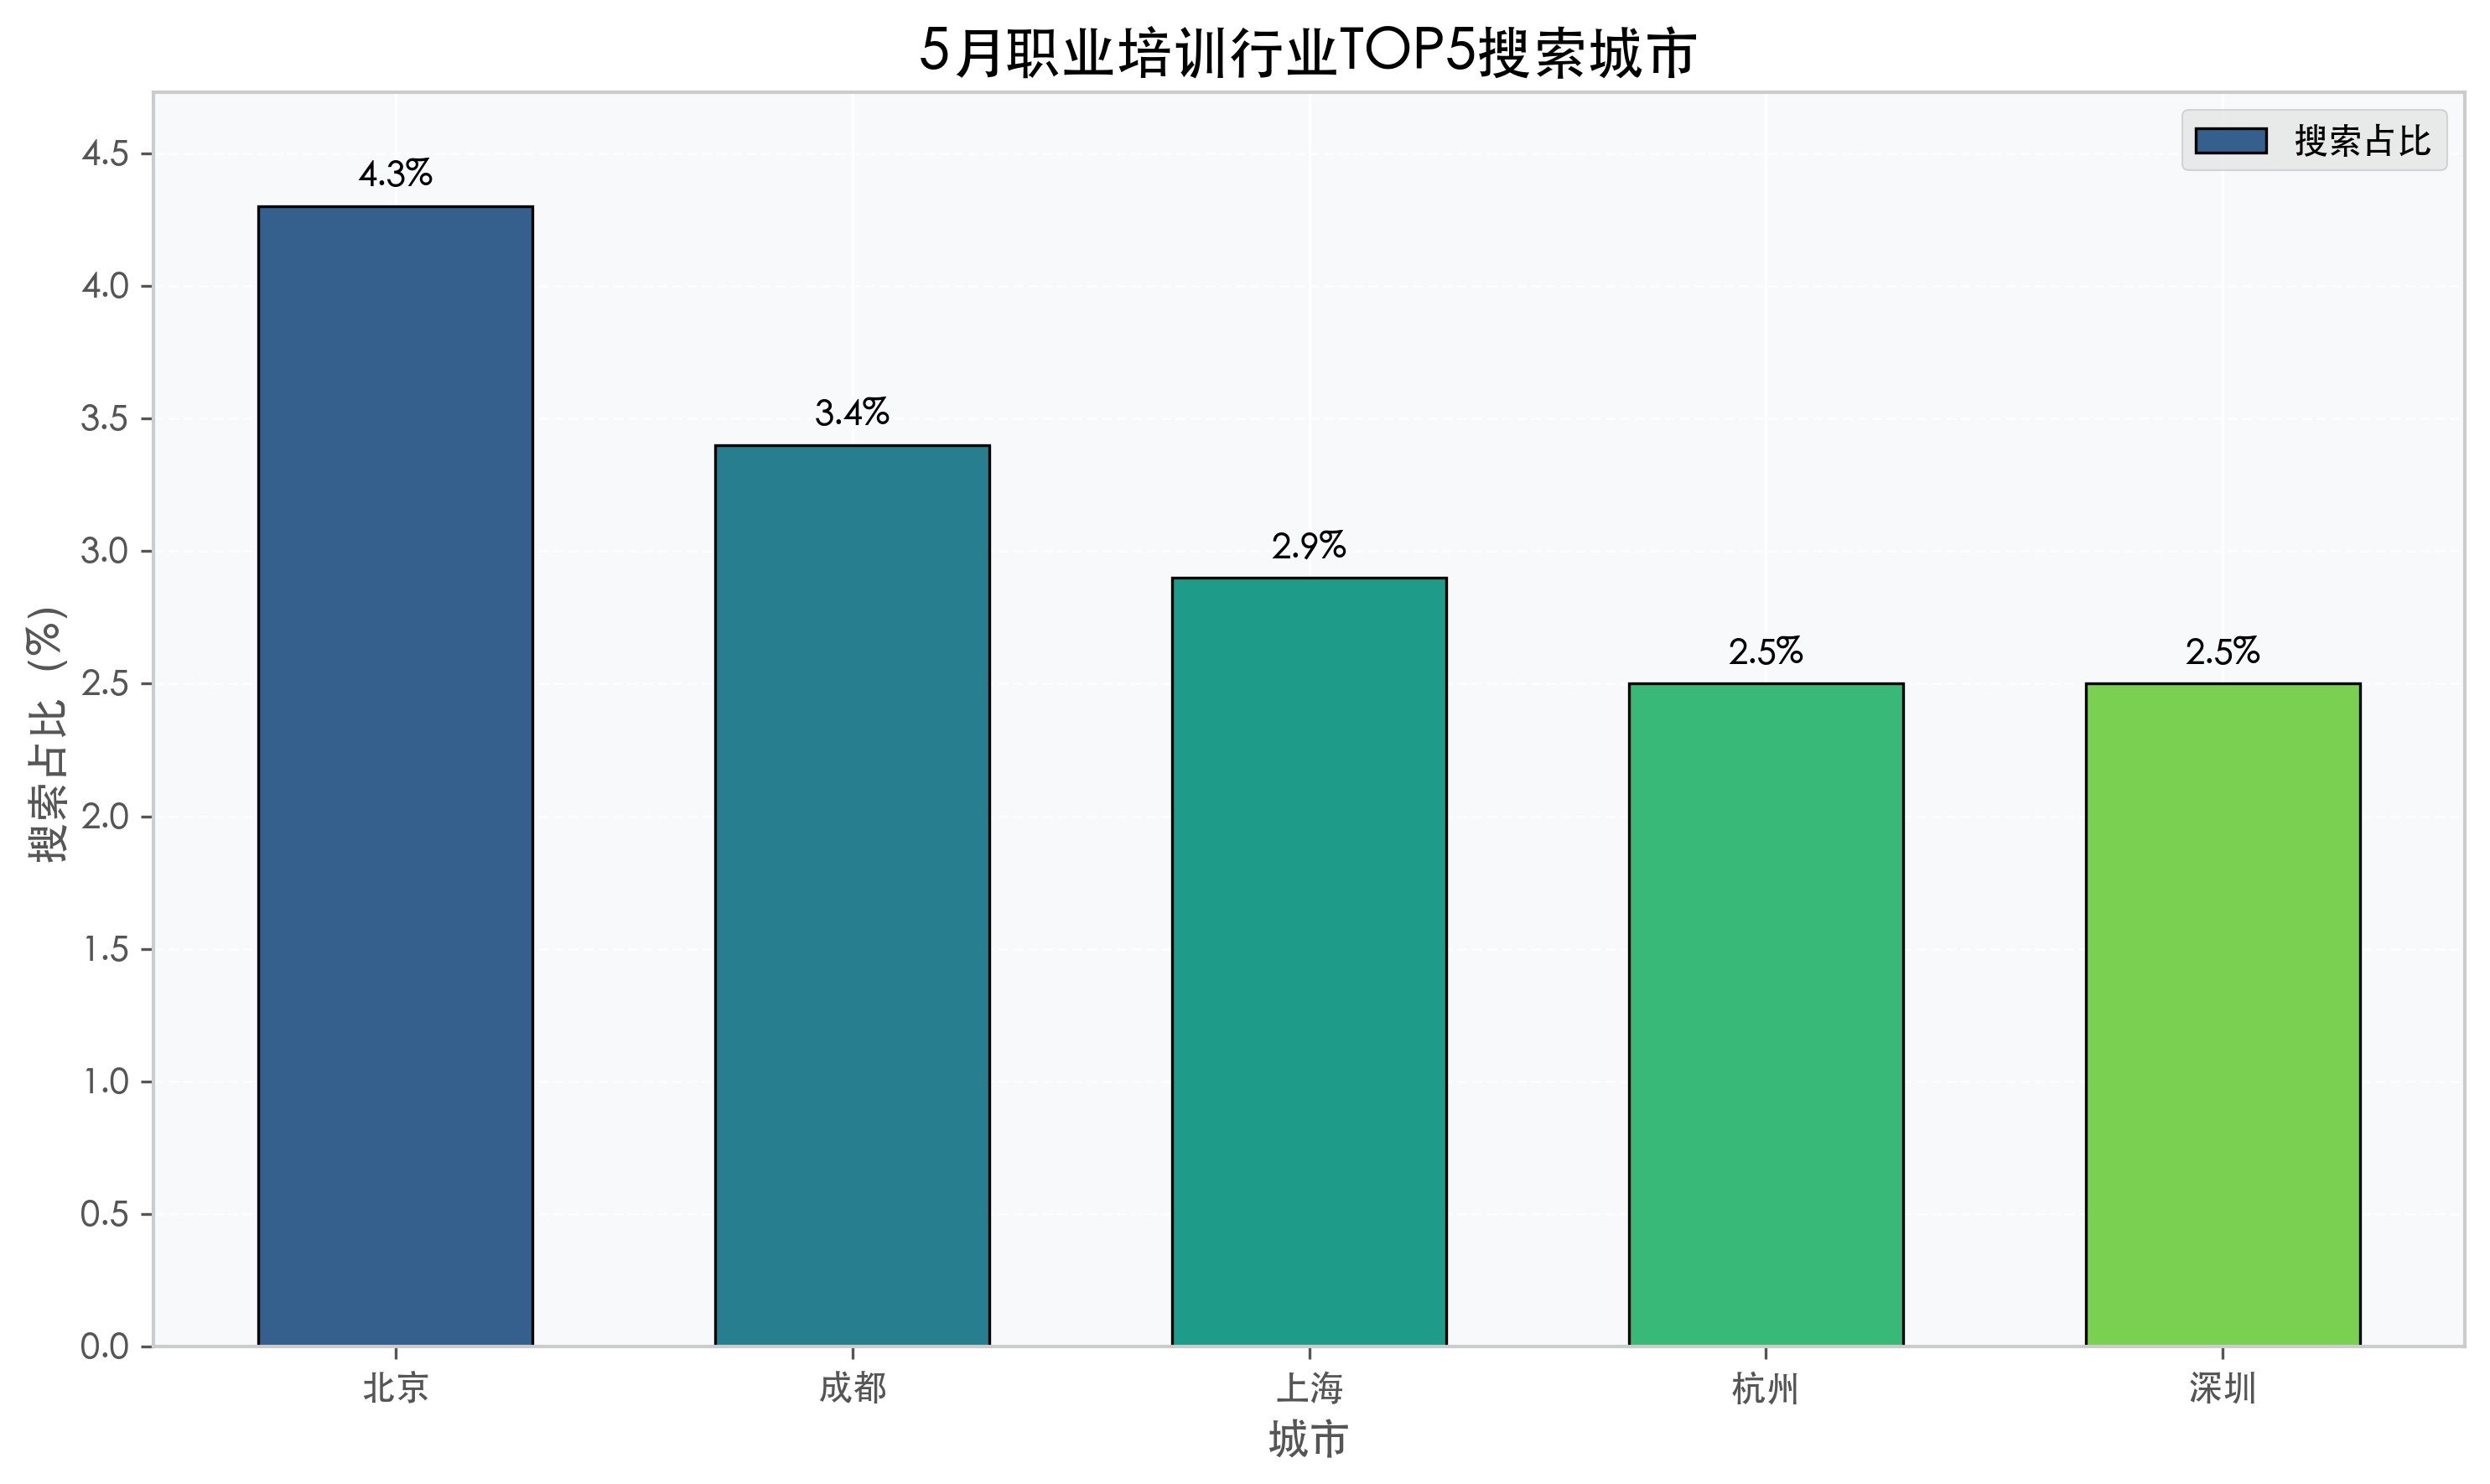

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
cities = ["北京", "成都", "上海", "杭州", "深圳"]
search_ratios = [4.3, 3.4, 2.9, 2.5, 2.5]

# 创建画布和子图
plt.figure(figsize=(10, 6), dpi=300)
ax = plt.subplot(111)

# 设置渐变色柱状图
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(cities)))
bars = plt.bar(cities, search_ratios, color=colors, width=0.6, edgecolor='black', linewidth=0.8)

# 添加数据标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height}%', ha='center', va='bottom', fontweight='bold')

# 添加标题和坐标轴标签
plt.title("5月职业培训行业TOP5搜索城市", fontsize=16, fontweight='bold')
plt.xlabel("城市", fontsize=12)
plt.ylabel("搜索占比（%）", fontsize=12)

# 设置坐标轴范围和刻度
plt.ylim(0, max(search_ratios) * 1.1)
plt.yticks(np.arange(0, 5, 0.5))

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加背景色
ax.set_facecolor('#f8f9fa')

# 调整边框
for spine in ax.spines.values():
    spine.set_color('#cccccc')

# 添加图例
plt.legend([bars[0]], ['搜索占比'], loc='upper right')

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()